In [111]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Logistic Regression can be used to predict probabilities as a binary classifier.

This model computes a weighted mean of all features, just like linreg. However, instead of outputting the direct vaslue of this mean, it outputs the logistic of this result. That is done by inputting output into a logistic function(Sigmoid, etc)

The cost fn for logreg is also convex 

FOR EQNS REFER 143 onwards

In [112]:
dataset = pd.read_csv("iris.csv")
print(dataset.isna().sum())
dataset["species"].unique()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [113]:
dataset["species"]

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object

In [114]:
X = dataset.drop(("species"), axis=1)
y = dataset["species"]

In [115]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
X_encoded = X
X_encoded["species"] = y_encoded
corrMatrix = X_encoded.corr()
corrMatrix
# Petal Length and Width is much higher corr than sepal length and width

,sepal_length,sepal_width,petal_length,petal_width,species
sepal_length,1.000000,-0.109369,0.871754,0.817954,0.782561
sepal_width,-0.109369,1.000000,-0.420516,-0.356544,-0.419446
petal_length,0.871754,-0.420516,1.000000,0.962757,0.949043
petal_width,0.817954,-0.356544,0.962757,1.000000,0.956464
species,0.782561,-0.419446,0.949043,0.956464,1.000000


In [116]:
from sklearn.model_selection import train_test_split

y= (y =="virginica").astype(int) # binary classification
xTrain,xTest,yTrain,yTest = train_test_split(X,y)
for df in xTrain,xTest:
    df.drop(["sepal_length", "sepal_width", "species"], axis=1, inplace=True)
    df = np.c_[np.ones( (len(df),1) ),df]
yTest = encoder.fit_transform(yTest)
yTrain = encoder.fit_transform(yTrain)
yTest=np.reshape(np.ravel(yTest),(len(yTest),1))
yTrain=np.reshape(np.ravel(yTrain),(len(yTrain),1))
xTestN = np.c_[np.ones( (len(xTest),1) ),xTest]
xTrainN = np.c_[np.ones( (len(xTrain),1) ),xTrain]

In [117]:
def hypothesis(t):
    return 1/(1+np.exp(-t))

def Logistic_Regression(X,y, n_epochs,eta):
    theta = np.random.rand(3,1)
    m = len(X)
    X=np.array(X)
    for i in range(n_epochs):
        gradient = 1/m * ((hypothesis(np.matmul(X,theta)) - y).T).dot(X)
        theta  = theta-eta*gradient.T
    return theta
theta = Logistic_Regression(xTrainN,yTrain,100,0.5)
preds = np.matmul(xTestN,theta)
preds = (preds>=0.5).astype(int) 

In [118]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logreg = LogisticRegression()
logreg.fit(xTrain,yTrain.ravel())
predsSk = logreg.predict(xTest) #by sklearn
shitPreds = np.zeros(yTest.shape)

In [119]:
print(logreg.coef_,logreg.intercept_,'\n',theta)
intc = logreg.intercept_[0]
tw = logreg.coef_[0,0]
tl = logreg.coef_[0,1]

[[2.57177528 2.29423806]] [-16.1869919] 
 [[-3.26871741]
 [-0.03384145]
 [ 2.72639046]]


In [120]:
accSk = accuracy_score(yTest,predsSk)
acc = accuracy_score(yTest,preds)
accShit = accuracy_score(yTest,shitPreds)
print(accSk,acc,accShit)

0.9736842105263158 0.868421052631579 0.8421052631578947


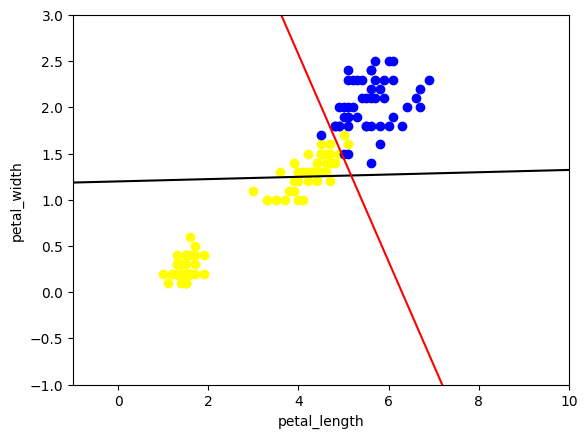

In [121]:
plt.scatter(xTrain[yTrain==0]["petal_length"],xTrain[yTrain==0]["petal_width"], color="yellow")
plt.scatter(xTest[yTest==0]["petal_length"],xTest[yTest==0]["petal_width"], color="yellow")
plt.scatter(xTrain[yTrain==1]["petal_length"],xTrain[yTrain==1]["petal_width"], color="blue")
plt.scatter(xTest[yTest==1]["petal_length"],xTest[yTest==1]["petal_width"], color="blue")
plt.xlabel("petal_length")
plt.ylabel("petal_width")

plt.axline((0, -theta[0,0]/theta[2,0]), (-theta[0,0]/theta[1,0],0), color="black")
plt.axline((0,-intc/tl), (-intc/tw,0), color="red")
plt.xlim(-1,10)
plt.ylim(-1,3)
plt.show()